# Stress & Strain Post-Processing Code

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from scipy.stats import linregress
import seaborn as sns
import sounddevice as sd

import mplcursors 

from scipy.signal import welch # We'll need this for power spectral density estimation 

%matplotlib inline

In [48]:
VCC         = 5.01          # Measured supply voltage (V)
GF          = 2.11          # Gauge factor from spec sheet

# Beam geometry
L           = 10.24 * 0.0254        # Cantilever length: 10.24 in → meters
b           = 0.47  * 0.0254        # Width: 0.47 in → meters
h           = 0.0984 * 0.0254       # Height: 0.0984 in → meters
E_psi       = 10_000_000            # Young's modulus (psi)
E_pa        = E_psi * 6894.76       # Convert to Pascals

# Derived geometry
I = (b * h**3) / 12                 # Second moment of area (m^4)
ymax = h / 2                         # Distance from neutral axis to outer surface (m)

# File paths 
DATA_DIR = "/Users/caroline/Desktop/geng360-mahoney/Lab 4 - Beam/"
files = {
    0:   "no_strain.csv",
    10:  "10g.csv",
    20:  "20g.csv",
    30:  "30g.csv",
    50:  "50g.csv",
    100: "100g.csv",
}

print(f"Beam: L={L*100:.2f} cm, b={b*100:.2f} cm, h={h*100:.3f} cm") # .2f and .3f used to display a certain number of decimals. Multiplying by 100 converts from m to cm
print(f"I = {I:.4e} m^4,  ymax = {ymax*1000:.3f} mm")

Beam: L=26.01 cm, b=1.19 cm, h=0.250 cm
I = 1.5532e-11 m^4,  ymax = 1.250 mm


Unstrained baseline (Vout/Vin) = 0.00209006
Raw ADC mean (unstrained)      = 4488360.56


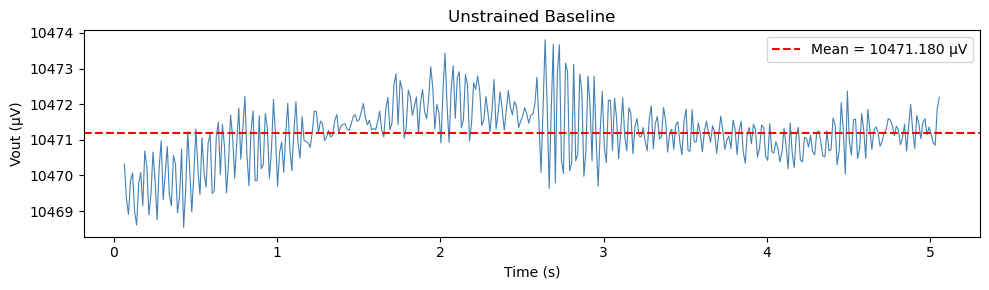

In [49]:
unstrained_raw = pd.read_csv(DATA_DIR + files[0]) # so we don't have to keep re-reading

# Convert raw ADC → voltage
unstrained_raw["vout"] = (unstrained_raw["strain (raw)"] / 128) * (VCC / 16777215)

# Baseline: average Vout/Vin when unstrained
baseline_vout_over_vin = (unstrained_raw["vout"] / VCC).mean()

print(f"Unstrained baseline (Vout/Vin) = {baseline_vout_over_vin:.8f}")
print(f"Raw ADC mean (unstrained)      = {unstrained_raw['strain (raw)'].mean():.2f}")

# Unstrained baseline plot
plt.figure(figsize=(10, 3)) # adjust width and height to accommodate wide range of samples
plt.plot(unstrained_raw["Times (us)"] / 1e6, unstrained_raw["vout"] * 1e6, color="steelblue", linewidth=0.8)
plt.axhline(unstrained_raw["vout"].mean() * 1e6, color="red",
            linestyle="--", label=f"Mean = {unstrained_raw['vout'].mean()*1e6:.3f} µV") # adds a horizontal line at the mean value of Vout, with a label showing the mean in microvolts
plt.title("Unstrained Baseline")
plt.xlabel("Time (s)")
plt.ylabel("Vout (µV)")
mplcursors.cursor(hover=False)
plt.legend()
plt.tight_layout()
plt.show()

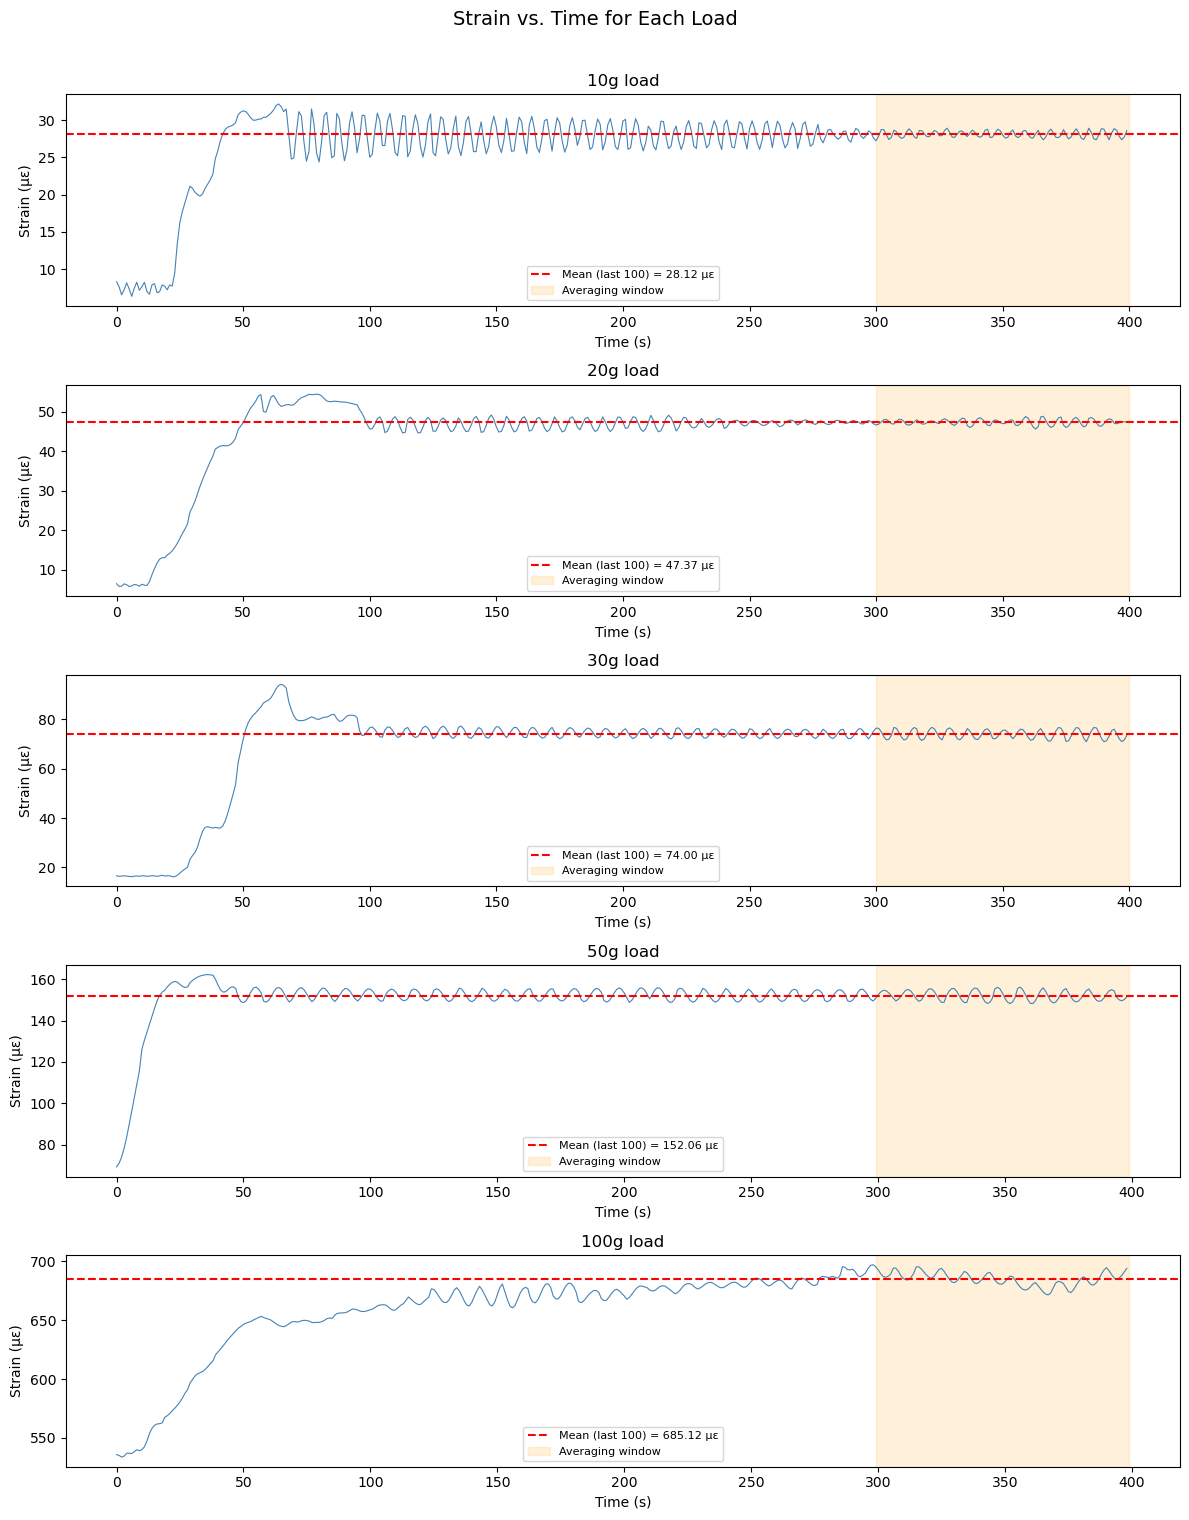

 load_g  measured_strain   strain_std
     10         0.000028 4.646058e-07
     20         0.000047 7.450138e-07
     30         0.000074 1.843176e-06
     50         0.000152 2.411919e-06
    100         0.000685 5.827378e-06


In [50]:
loads_g = [10, 20, 30, 50, 100]
results = []

# Get unstrained mean from the already-loaded unstrained_raw
unstrained_mean = unstrained_raw["strain (raw)"].mean()

# Create subplots for each load
fig, axes = plt.subplots(len(loads_g), 1, figsize=(12, 3 * len(loads_g)), sharex=False)
# fig: whole window
# axes: array of individual plots (one per load)
# 1: number of columns (we want them stacked vertically)
# 3 * len(loads_g): height of each subplot, multiplied by number of loads to get total figure height
# sharex=False: allows each subplot to have its own x-axis

for ax, load in zip(axes, loads_g): # zip: lets you loop through both axes and loads_g together
    # Load data — NO inversion
    df = pd.read_csv(DATA_DIR + files[load])

    # Compute Vr per sample using raw difference from baseline
    raw_diff = df["strain (raw)"] - unstrained_mean
    df["vr"] = (raw_diff / 128) * (VCC / 16777215) / VCC   # ← divide by VCC here

    # Vr → Strain
    df["strain"] = (4 * df["vr"]) / (GF * (1 + 2 * df["vr"])) 

    # Use last 100 samples (most stable)
    mean_strain = df["strain"].tail(100).mean()
    std_strain  = df["strain"].tail(100).std()

    results.append({
        "load_g":          load,
        "measured_strain": mean_strain,
        "strain_std":      std_strain,
    })

    # Plot
    ax.plot(df["strain"] * 1e6, color="steelblue", linewidth=0.8)
    ax.axhline(mean_strain * 1e6, color="red", linestyle="--", label=f"Mean (last 100) = {mean_strain*1e6:.2f} µε")  # horizontal line along mean strain value
    ax.axvspan(len(df) - 100, len(df), alpha=0.15, color="orange", label="Averaging window") # highlights last 100 samples with a shaded area
    ax.set_title(f"{load}g load")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Strain (µε)")
    ax.legend(fontsize=8)

plt.suptitle("Strain vs. Time for Each Load", fontsize=14, y=1.01)
mplcursors.cursor(hover=False)
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False)) # converts DataFrame to string for printing
# index = False to hide the row numbers on the left side

In [51]:
g_to_N = 9.81 / 1000   # grams-force → Newtons

# convert loads from g to N
results_df["load_N"]               = results_df["load_g"] * g_to_N
# compute theoretical stress and strain, measured stress, and percent difference
results_df["theoretical_stress_Pa"] = (results_df["load_N"] * L * ymax) / I
results_df["theoretical_strain"]    = results_df["theoretical_stress_Pa"] / E_pa
results_df["measured_stress_Pa"]    = results_df["measured_strain"] * E_pa
results_df["pct_diff"] = (
    abs(results_df["measured_strain"] - results_df["theoretical_strain"])
    / results_df["theoretical_strain"] * 100
)

display_df = results_df[["load_g", "theoretical_strain", "measured_strain",
                          "theoretical_stress_Pa", "measured_stress_Pa", "pct_diff"]].copy()
display_df["theoretical_strain"] *= 1e6
display_df["measured_strain"]    *= 1e6
display_df.columns = ["Load (g)", "Theoretical (µε)", "Measured (µε)",
                       "Theoretical Stress (Pa)", "Measured Stress (Pa)", "% Diff"]

print(display_df.to_string(index=False)) # convert to string for printing, hide index with index=False

 Load (g)  Theoretical (µε)  Measured (µε)  Theoretical Stress (Pa)  Measured Stress (Pa)     % Diff
       10         29.774575      28.118947             2.052885e+06          1.938734e+06   5.560542
       20         59.549150      47.369724             4.105771e+06          3.266029e+06  20.452729
       30         89.323725      74.004786             6.158656e+06          5.102452e+06  17.149911
       50        148.872876     152.060175             1.026443e+07          1.048418e+07   2.140954
      100        297.745751     685.115896             2.052885e+07          4.723710e+07 130.100981


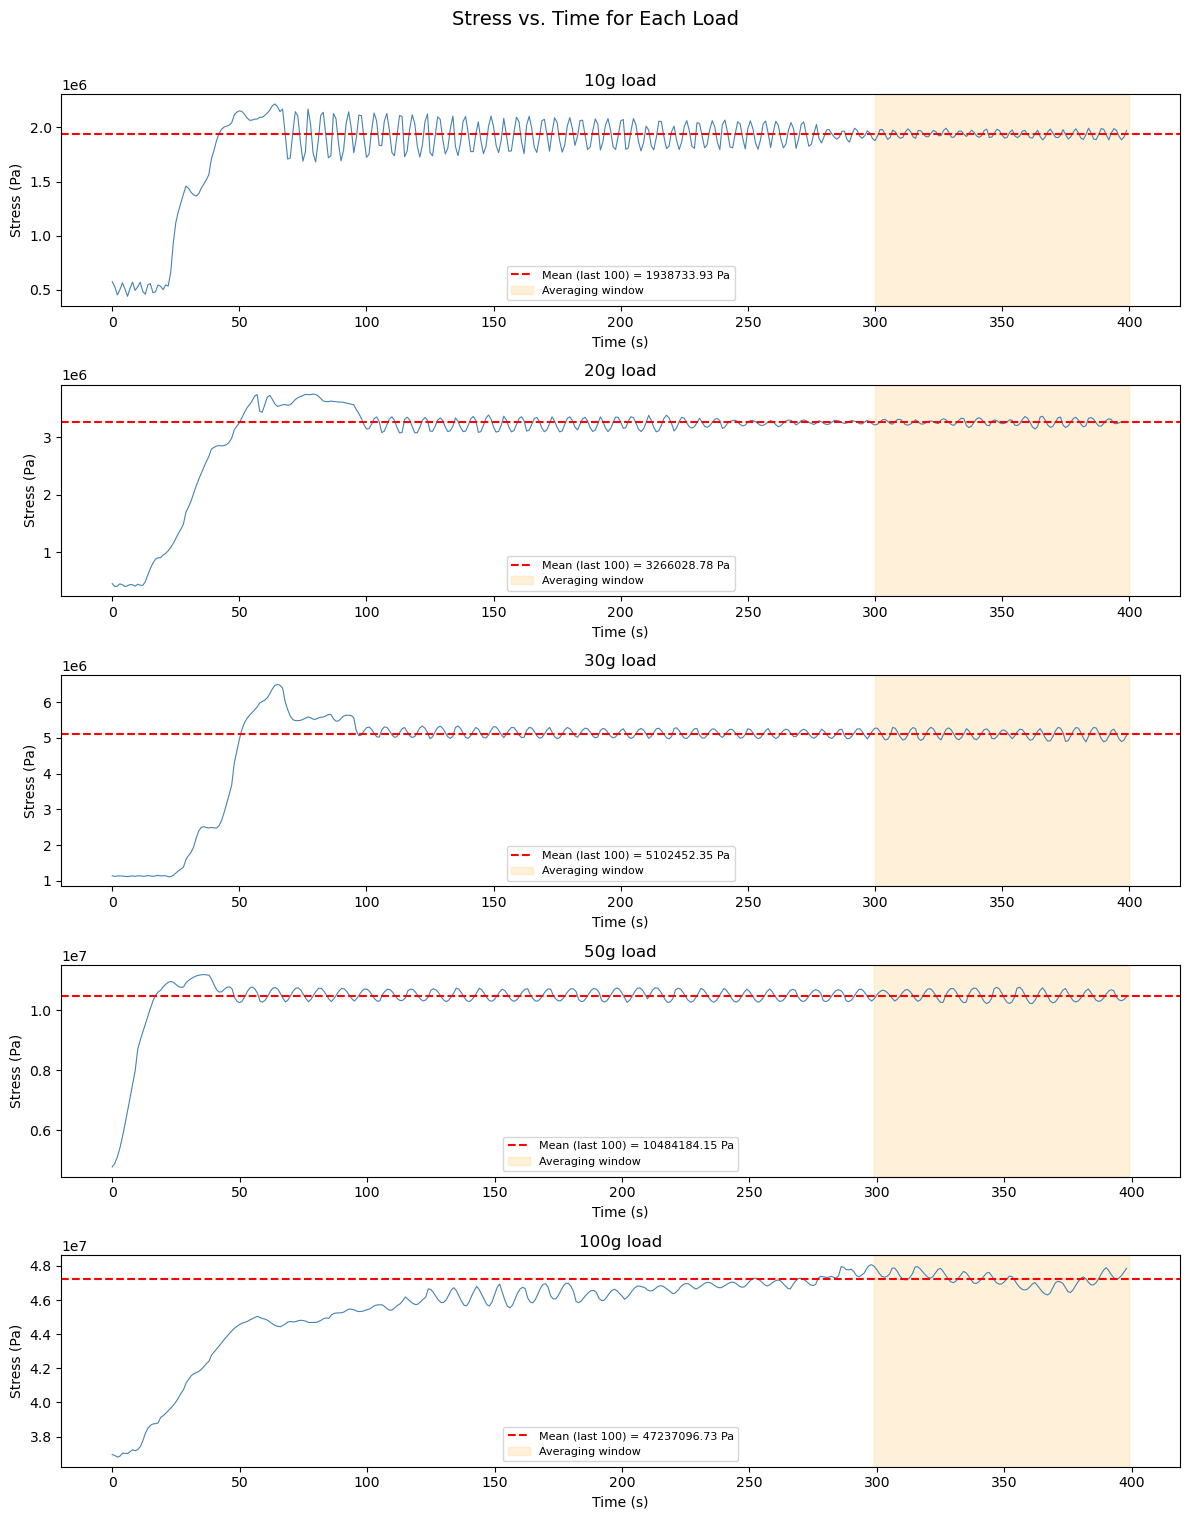

In [52]:
g_to_N = 9.81 / 1000   # grams-force → Newtons

fig, axes = plt.subplots(len(loads_g), 1, figsize=(12, 3 * len(loads_g)), sharex=False)

for ax, load in zip(axes, loads_g):

    df = pd.read_csv(DATA_DIR + files[load])

    raw_diff = df["strain (raw)"] - unstrained_mean
    df["vr"] = (raw_diff / 128) * (VCC / 16777215) / VCC
    df["strain"] = (4 * df["vr"]) / (GF * (1 + 2 * df["vr"]))

    # Convert strain → stress 
    df["stress_Pa"] = df["strain"] * E_pa

    # Mean over last 100 samples
    mean_stress = df["stress_Pa"].tail(100).mean()

    # Plot 
    ax.plot(df["stress_Pa"], color="steelblue", linewidth=0.8)

    ax.axhline(mean_stress, color="red", linestyle="--",
               label=f"Mean (last 100) = {mean_stress:.2f} Pa")

    ax.axvspan(len(df) - 100, len(df),
               alpha=0.15, color="orange", label="Averaging window")

    ax.set_title(f"{load}g load")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Stress (Pa)")
    ax.legend(fontsize=8)

plt.suptitle("Stress vs. Time for Each Load", fontsize=14, y=1.01)
mplcursors.cursor(hover=False)
plt.tight_layout()
plt.show()

In [53]:
print("=== RAW ADC DIAGNOSTICS ===")
print(f"{'Load':>8} | {'Raw Mean':>12} | {'Diff from baseline':>20} | Direction")
print("-" * 65)

baseline_mean = pd.read_csv(DATA_DIR + files[0])["strain (raw)"].mean()

for load in loads_g:
    df = pd.read_csv(DATA_DIR + files[load])
    raw_mean = df["strain (raw)"].tail(100).mean()
    diff = raw_mean - baseline_mean
    direction = "↑ positive strain" if diff > 0 else "↓ check inversion!"
    print(f"{load:>6}g | {raw_mean:>12.1f} | {diff:>20.1f} | {direction}")

print(f"\nBaseline mean: {baseline_mean:.1f}")

=== RAW ADC DIAGNOSTICS ===
    Load |     Raw Mean |   Diff from baseline | Direction
-----------------------------------------------------------------
    10g |    4520214.6 |              31854.0 | ↑ positive strain
    20g |    4542023.5 |              53663.0 | ↑ positive strain
    30g |    4572199.5 |              83839.0 | ↑ positive strain
    50g |    4660641.6 |             172281.0 | ↑ positive strain
   100g |    5265019.6 |             776659.0 | ↑ positive strain

Baseline mean: 4488360.6
